<a href="https://colab.research.google.com/github/ramyavalipe/GenAIColabNotebooks/blob/main/CIFAR10_XGBoost_CrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIS382N: Homework 2


Submit:

A read-only link to your colab notebook, executed and saved (so that we can run it, but don't necessarily have to, to see your results).

For any questions that require written explanation, please use Markdown - it is a lot easier for us to read than comments in the code.

**If you used any AI help, please describe how you used it and what you used.**




Names: Ramya Valipe, Connor Case, Nicholas Tran

AI Statement:

Used Chat GPT to help with syntax of code, manipulating old code snippets for new data sets, problems 2 & 3 AI was used for GPU and ram optimization. Used it to help us structure the notebook into modular cells with pseudocode.

Concepts about over/underfitting, variance, and bootstrap intuition were aligned with our class notebooks



## Import Libraries


In [ ]:
# Some useful libraries
import numpy as np
from numpy.random import default_rng

# Pandas for data structure and analysis tools
import pandas as pd

# seaborn and matplotlib for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# for nice vector graphics
%matplotlib inline

# Scikit-learn for machine learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# PyTorch for CIFAR-10 dataset
import torch
import torchvision
import torchvision.transforms as transforms

np.random.seed(42) # Fixed seed for reproducibility
rng = default_rng(42)


Setup

In [ ]:
# PSEUDOCODE
# - Install xgboost
# - Import core libs (numpy, pandas, matplotlib)
# - Import sklearn models/utilities
# - Import torch/torchvision for CIFAR-10
# - Fix random seeds
!pip -q install xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import torch, torchvision, torchvision.transforms as transforms
from xgboost import XGBClassifier

np.random.seed(42)
rng = default_rng(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## Problem 1: CIFAR-10

**NB**: for much of the above, you may want to work with a subset of the training data if you find that computation times are too much. You should always be testing on the full testing data set.

### Part A:

**Load CIFAR-10 Dataset**

Last time we used ``keras`` to download this dataset.
This time, figure out how to load it with ``Pytorch``.
**Download** train and test data from ``torchvision``**
** Apply transforms** to convert the data to the tensor format that ``pytorch`` requires. Also normalize. You can use this command:
```
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
```


In [ ]:
# PSEUDOCODE
# - Define transforms: ToTensor + Normalize
# - Download CIFAR-10 train/test
# - (Optional) subsample train for speed while developing
# - Create DataLoaders (no shuffle needed for feature export)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# for quick iteration while developing; set to None for full train
train_subset_size = None  # e.g., 10000
if train_subset_size:
    idx = np.random.choice(len(trainset), size=train_subset_size, replace=False)
    trainset = torch.utils.data.Subset(trainset, idx)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=False, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=512, shuffle=False, num_workers=2)

def to_xy(dataloader):
    X_chunks, y_chunks = [], []
    for xb, yb in dataloader:
        X_chunks.append(xb.view(xb.size(0), -1).numpy())  # flatten [B,3,32,32] -> [B,3072]
        y_chunks.append(yb.numpy())
    return np.vstack(X_chunks), np.concatenate(y_chunks)

X_train, y_train = to_xy(trainloader)
X_test,  y_test  = to_xy(testloader)
print("X_train/X_test:", X_train.shape, X_test.shape)


100%|██████████| 170M/170M [00:05<00:00, 29.3MB/s]


X_train/X_test: (50000, 3072) (10000, 3072)


### Part B:

Train trees of depth 1 to 15 and plot accuracies

(You've basically already done this)


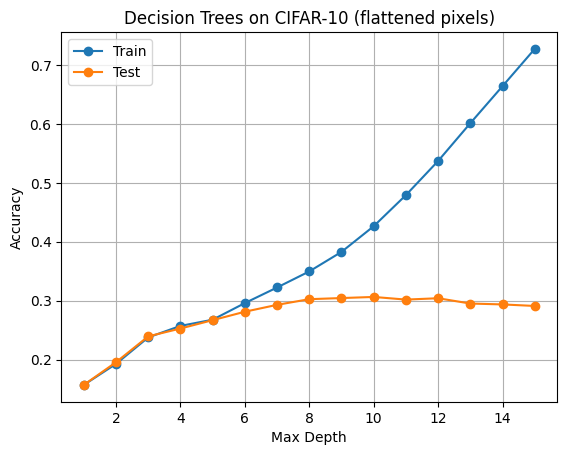

Best single-tree test accuracy: 0.3063 at depth=10


In [ ]:
# PSEUDOCODE
# - Loop depths = 1..15
# - Fit DecisionTree on X_train,y_train
# - Record train/test accuracy
# - Plot both curves; print best test depth
depths = list(range(1, 16))
train_acc, test_acc = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  clf.predict(X_test)))

plt.figure()
plt.plot(depths, train_acc, marker="o", label="Train")
plt.plot(depths, test_acc,  marker="o", label="Test")
plt.xlabel("Max Depth"); plt.ylabel("Accuracy"); plt.title("Decision Trees on CIFAR-10 (flattened pixels)")
plt.legend(); plt.grid(True); plt.show()

best_depth = depths[int(np.argmax(test_acc))]
print(f"Best single-tree test accuracy: {max(test_acc):.4f} at depth={best_depth}")


As the depth of the trees increased, the train datasets performed better while the test datasets plateaued in performance around depth 8 trees. This suggests that the model is overfitted to the train datasets and so cannot perform as well on the test datasets. The best tree was at depth 10 with an accuracy of 0.31.

### Part C:

Train a random forest with 3 trees of depth 12. How does this compare to trees of depth 12? Can you explain what you see, especially in regards to **training error**.

See if you can change any of the hyperparameters in order to obtain comparable training error with the depth 12 tree.

(Read Documentation of SK Learn)

In [ ]:
# PSEUDOCODE
# - Fit single tree depth=12
# - Fit RF with n_estimators=3, max_depth=12
# - Optionally try bootstrap=False to shrink bias
def report(model, name):
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:24s} | train {tr:.4f} | test {te:.4f}")

tree12 = DecisionTreeClassifier(max_depth=12, random_state=42).fit(X_train, y_train)
rf3_d12 = RandomForestClassifier(n_estimators=3, max_depth=12, random_state=42, n_jobs=-1).fit(X_train, y_train)
report(tree12, "Tree depth=12")
report(rf3_d12, "RF 3 trees depth=12")

# Try tweak: no bootstrap (reduces randomness; may lower bias, raise variance)
rf3_d12_noboot = RandomForestClassifier(n_estimators=3, max_depth=12, bootstrap=False,
                                        random_state=42, n_jobs=-1).fit(X_train, y_train)
report(rf3_d12_noboot, "RF 3 trees d=12 (no bootstrap)")


Tree depth=12            | train 0.5371 | test 0.3041
RF 3 trees depth=12      | train 0.5730 | test 0.3172
RF 3 trees d=12 (no bootstrap) | train 0.6691 | test 0.3451


The random forest without bootstrapping performed better becase the number of trees in the random forest is tiny (only 3). Since the random forest with bootstrapping only sees a sample of the data, its accuracy is not going to be as high because there are fewer trees that it can average together. The random forest without bootstrapping sees the whole dataset so it is able to be more accurate with fewer trees. The issue is that the model is still overfitting because the jump in training accuracy between the boostrapped and non-bootstrapped models was not reflected in the jump in testing accuracy between the two models.

### Problem D:

Train a Random Forest with 100 shallow trees (depth 3).

Please provide your observations about the Random Forest with shallow trees here. What do you observe? Is this what you expected? Consider:
- How does the performance compare to a single tree of the same depth?
- What might be the benefits and limitations of using many shallow trees?

(Don't train shallow as accuracy falls with RF) Not improving each other

Boosting you only want shallow trees; improving and lowering variance

In [ ]:
# PSEUDOCODE
# - Fit RF with 100 trees, max_depth=3
rf100_d3 = RandomForestClassifier(n_estimators=100, max_depth=3,
                                  random_state=42, n_jobs=-1).fit(X_train, y_train)
report(rf100_d3, "RF 100 trees depth=3")


RF 100 trees depth=3     | train 0.2861 | test 0.2915


The random forest of 100 trees at depth 3 performed better than the single tree at depth 3. However, performance overall is still quite low. The model has high underfitting risks because the depth of the trees are so low.However, whatever variance risk there was has been negated by training a random forest of 100 trees and then averaging the results. The gap between the training and testing accuracy is low because variance is low. The main benefits of using many shallow trees lies in what you gain by having low variance, such as with a small and noisy dataset. However, you are limited by the high bias the model has where there is a risk of underfitting if you have a large dataset with complex relationships in the data.

### Problem E:

Train a Random Forest with 100 deep trees (depth 12 or 15).

Do your observations match with what you expect?  


In [ ]:
# PSEUDOCODE
# - Fit RF 100 trees with depths 12 and 15; compare
rf100_d12 = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1).fit(X_train, y_train)
rf100_d15 = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1).fit(X_train, y_train)
report(rf100_d12, "RF 100 trees depth=12")
report(rf100_d15, "RF 100 trees depth=15")


RF 100 trees depth=12    | train 0.8245 | test 0.4473
RF 100 trees depth=15    | train 0.9586 | test 0.4609


The results of a random forest of 100 trees at either depth 12 or depth 15 makes sense with how random forests work. Because the number of trees has become more significant (100) and they are no longer shallow trees, the testing accuracy has greatly improved and has surpassed the accuracy of the best performing single tree model (depth 10). This suggests that the random forest was able to properly randomly sample data from a complex dataset, randomly select feature splits (and had more opportunity to do so), and then average the predictions of all of the trees to get a train and test accuracy that outperforms other models.

## Problem 2: XGBoost

### Problem A:

Download XGBoost and train 100 boosted depth-3 trees.

In [ ]:
# PSEUDOCODE
# - Fit XGB depth=3, 100 trees
def report(model, name):
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:24s} | train {tr:.4f} | test {te:.4f}")

xgb_d3_100 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=1.0, colsample_bytree=1.0,
    objective="multi:softmax", num_class=10,
    tree_method="hist", eval_metric="mlogloss",
    random_state=42, n_jobs=-1
)
xgb_d3_100.fit(X_train, y_train)
report(xgb_d3_100, "XGB depth=3, 100 trees")


XGB depth=3, 100 trees   | train 0.5189 | test 0.4477


### Problem B:

Train very deep trees and report on what you observe.

In [ ]:
# PSEUDOCODE
# - Load CIFAR-10
# - Reduce dimensionality
# - Build DMatrix
# - GPU configuration
# - Train and evaluate depth 12 trees with XGB

import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_openml
import numpy as np

X, y = fetch_openml("CIFAR_10", version=1, return_X_y=True, as_frame=False)
X = (X.astype(np.float32) / 255.0)
y = y.astype(np.int32)

pca = PCA(n_components=256, random_state=42)
X_pca = pca.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    "max_depth": 12,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "multi:softmax",
    "num_class": 10,
    "tree_method": "hist",
    "device": "cuda",
    "grow_policy": "lossguide",
    "eval_metric": "mlogloss",
    "random_state": 42,
}

xgb_model = xgb.train(params, dtrain, num_boost_round=100)
y_pred = xgb_model.predict(dtest)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.495


The output of 100 boosted trees at depth 12 is accurate with a 1.0 training score, and a 0.5276 testing score. This huge disparity between the training score and the testing score shows a classic case of overfitting. The accuracy score on the testing dataset is the highest it has been in comparison to all previous trees. It makes sense that this model would perform better than the 100 boosted trees at depth 3 because the deep trees are better able to classify the dataset.

### Problem C:

Use any combination of tree-based methods with any subset of the training data you think is best, to try to achieve the highest testing error.

In [ ]:
# PSEUDOCODE
# - Choose tuned hyperparams: more trees = better accuracy, slower training, moderate depth avoids overfitting,
# - smaller learning rate for smoother learning, subsample and feature sample helps generalization

from xgboost import XGBClassifier

xgb_best_try = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="multi:softmax",
    num_class=10,
    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_best_try.fit(X_train, y_train)

report(xgb_best_try, "XGB tuned (GPU-optimized)")


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:729: UserWarning: [00:11:46] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGB tuned (GPU-optimized) | train 0.7924 | test 0.5282


This loadout uses a tuned XGBoost classifier to achieve the highest testing accuracy.

We believe this is the best combination to achieve the highest testing accuracy because we used more trees to increase accuracy (300), used a moderate depth (5) to avoid overfitting, a smaller learning rate (0.05) for smoother learning, and subsampling of both rows and features to improve generalization and reduce variance.

For practical usage, we then applied L2 regularization to control model complexity and trained using the GPU-optimized histogram method for efficiency.

# Problem 3: Cross Validation

Read about the hyperparameters for XGBoost. In particular, read about learning rate, and L1 and L2 regularization. Use k-fold-CV to find good hyperparameters for XGBoost using the CIFAR-10 data. Try to search over at least 3 or 4 differences choices.

Note: if you run this with many trees on all 50000 training points, it may take a long time. You're welcome to do this. But the main goal is to make sure you know how CV works, and what are the available tools (e.g., GridSearch CV) that can help you implement it efficiently.

In [ ]:
#PSUEDOCODE
# - Load CIFAR10
# - Use PCA for memory efficiency
# - Take a subset of 10,000 of the data for GridSearch
# - Denote the hyperparameters
# - Perform classification
# - Perform stratified K-Fold CV
# - Peform GridSearch CV
# - Retrain best model on full dataset (train only)
# - Report train accuracies

import numpy as np
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score
import warnings

X, y = fetch_openml("CIFAR_10", version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int32)

pca = PCA(n_components=128, random_state=42)
X_pca = pca.fit_transform(X)

subset_size = 10000
subset_idx = np.random.choice(len(X_pca), size=subset_size, replace=False)
X_sub = X_pca[subset_idx]
y_sub = y[subset_idx]

param_grid = {
    "learning_rate": [0.1, 0.05],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "n_estimators": [100, 200],
    "reg_alpha": [0.0, 0.5],
    "reg_lambda": [1.0, 2.0]
}

xgb_base = XGBClassifier(
    objective="multi:softmax",
    num_class=10,
    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",
    n_jobs=4,
    random_state=42,
    use_label_encoder=False,
    verbosity=0
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    verbose=0,
    n_jobs=1
)

grid.fit(X_sub, y_sub)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_params = grid.best_params_

best_xgb = XGBClassifier(
    **best_params,
    objective="multi:softmax",
    num_class=10,
    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",
    n_jobs=4,
    random_state=42,
    use_label_encoder=False,
    verbosity=0
)

best_xgb.fit(X_pca, y)

y_pred = best_xgb.predict(X_pca)
print("Full-train accuracy:", accuracy_score(y, y_pred))

def report(model, name="Model"):
    print(f"Report for {name}:")
    print("Number of trees:", len(model.get_booster().get_dump()))
    print("Feature importances (first 10):", model.feature_importances_[:10])
    print("-" * 40)

report(best_xgb, "XGB (GridSearch best, full train)")


Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV accuracy: 0.44550075883413176
Full-train accuracy: 0.7263166666666667
Report for XGB (GridSearch best, full train):
Number of trees: 2000
Feature importances (first 10): [0.02477014 0.02889603 0.0253967  0.01806928 0.01793965 0.01543395
 0.01843695 0.00956484 0.02535802 0.00718421]
----------------------------------------


The CV score shows that these hyperparameters generalize better than the others on this subset of the data. CV accuracy is lower than full-train accuracy because it uses a subset of the dataset. The hyperparameters seem to work well as the full-train accuracy is similar to other models' training accuracy scores.